# COVID-19 Detection Using X-ray Images with ResNet101
This project leverages the ResNet101 deep learning model to analyze X-ray images and classify them based on COVID-19 presence. The dataset, "Covid19_Xray | ResNet," is processed using TensorFlow and Keras, with data augmentation applied to improve model robustness and generalization.

## Members
- Juan Sebastián Dosman
- Andrés Mauricio Bonilla

## Importing Libraries
The code imports essential libraries for:

1. System Operations - to handle file and directory operations.
2. Data Handling - for data manipulation, visualization, and train-test splitting.
3. Deep Learning Framework - to build, compile, and train the model using the ResNet101 architecture in TensorFlow and Keras.

In [47]:
# Importing System Libraries
import os  # Provides functions to interact with the operating system

# Importing Data Handling and Visualization Libraries
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For enhanced data visualization
sns.set_style('darkgrid')  # Setting the style for Seaborn plots
import matplotlib.pyplot as plt  # Core plotting library
from sklearn.model_selection import train_test_split  # To split data into training and testing sets

# Importing Kagglehub to load datasets directly from Kaggle
import kagglehub  # Note: Ensure Kaggle API is configured for data access

# Importing Deep Learning Libraries
import tensorflow as tf  # Core deep learning library
from tensorflow.keras.models import Sequential  # Sequential model API
from tensorflow.keras.optimizers import Adamax  # Optimizer choice
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # To perform data augmentation on images
from tensorflow.keras.layers import Dense, Dropout  # Layers for fully connected architecture
from tensorflow.keras.applications import ResNet101  # Pretrained ResNet101 architecture
from tensorflow.keras.callbacks import EarlyStopping  # Early stopping to prevent overfitting

# Suppressing Warnings for Cleaner Output
import warnings
warnings.filterwarnings("ignore")  # Ignores warnings for clearer output

## Downloading the Dataset
The code connects to Kaggle, retrieves the "Covid19_Xray | ResNet" dataset, and verifies the download path. Ensure that your Kaggle API key is correctly configured to allow data access.

In [30]:
# Downloading the latest version of the "Covid19_Xray | ResNet" dataset using Kaggle Hub
path = kagglehub.dataset_download("khoongweihao/covid19-xray-dataset-train-test-sets")

# Verifying successful download by printing the file path
print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\salas\.cache\kagglehub\datasets\khoongweihao\covid19-xray-dataset-train-test-sets\versions\1


In [31]:
# Define the base directory for the "Covid19_Xray | ResNet" dataset images
BASE_DIR = "C:/Users/salas/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/train"

## Generating File Paths and Labels
The code iterates over the dataset directory structure to gather the full file paths for each image and assigns the folder name as the label. These paths and labels are stored in separate lists, which are later converted to pandas Series for convenient data manipulation.

In [32]:
# Initializing lists to store file paths and corresponding labels
filepaths = []  # List to hold the complete paths for each image file
labels = []     # List to hold labels corresponding to each image

# Retrieving folder names (labels) from the base directory
folds = os.listdir(BASE_DIR)

# Iterating over each folder (label) in the base directory
for fold in folds:
    foldpath = os.path.join(BASE_DIR, fold)  # Constructing the full path to the folder
    filelist = os.listdir(foldpath)  # Listing all files within the folder

    # Iterating over each file in the current folder
    for file in filelist:
        fpath = os.path.join(foldpath, file)  # Constructing the full file path

        filepaths.append(fpath)  # Storing the file path
        labels.append(fold)  # Storing the folder name as the label

# Creating Pandas Series for file paths and labels
Fseries = pd.Series(filepaths, name='filepaths')  # Series for image file paths
Lseries = pd.Series(labels, name='labels')  # Series for image labels


## Creating the Training DataFrame for COVID-19 X-ray Dataset

In this step, we combine the file paths and labels into a single DataFrame to organize our dataset for model training. This DataFrame will serve as the foundation for data loading and augmentation in later stages.

In [33]:
# Combining file paths and labels into a single DataFrame
train_df = pd.concat([Fseries, Lseries], axis=1)  # Concatenate Series along columns
train_df  # Display the resulting DataFrame

,filepaths,labels
0,C:/Users/salas/.cache/kagglehub/datasets/khoon...,NORMAL
1,C:/Users/salas/.cache/kagglehub/datasets/khoon...,NORMAL
2,C:/Users/salas/.cache/kagglehub/datasets/khoon...,NORMAL
3,C:/Users/salas/.cache/kagglehub/datasets/khoon...,NORMAL
4,C:/Users/salas/.cache/kagglehub/datasets/khoon...,NORMAL
...,...,...
143,C:/Users/salas/.cache/kagglehub/datasets/khoon...,PNEUMONIA
144,C:/Users/salas/.cache/kagglehub/datasets/khoon...,PNEUMONIA
145,C:/Users/salas/.cache/kagglehub/datasets/khoon...,PNEUMONIA
146,C:/Users/salas/.cache/kagglehub/datasets/khoon...,PNEUMONIA


## Class Distribution Visualization for COVID-19 X-ray Dataset

This section visualizes the class distribution in the dataset, helping us understand the balance between different categories. Visualizing class counts is crucial in datasets where class imbalance can affect model performance.

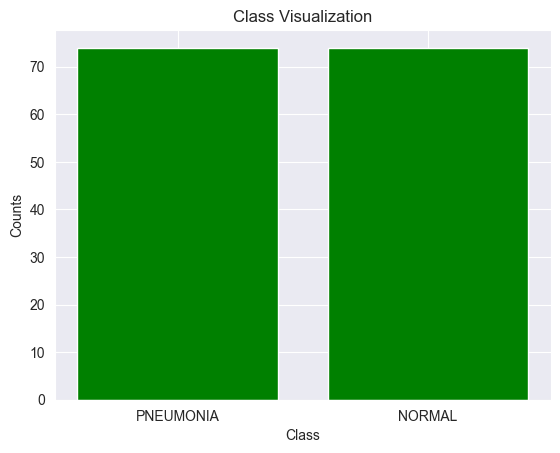

In [34]:
# Counting the occurrences of each class in the labels column
x = train_df["labels"].value_counts()  # Series with class counts

# Creating a figure to visualize the distribution of classes
plt.figure()

# Labels for the classes in the dataset
class_labels = ["PNEUMONIA", "NORMAL"]

# Creating a bar chart to show sample counts for each class
plt.bar(class_labels, x.values, color="green")  # Setting bar color to green

# Adding titles and labels for better readability
plt.title("Class Distribution")  # Title of the chart
plt.xlabel("Class")  # Label for the X-axis
plt.ylabel("Counts")  # Label for the Y-axis

plt.show()  # Display the bar chart

## Splitting the COVID-19 X-ray Dataset: Validation and Test Sets

In this section, we split the main training DataFrame into separate validation and test sets. This split allows us to evaluate model performance on unseen data and fine-tune model hyperparameters before final testing.

In [35]:
# Splitting the training DataFrame into validation and test sets
valid_df, test_df = train_test_split(
    train_df,  # Main DataFrame to split
    train_size=0.5,  # Proportion of data allocated to the validation set
    shuffle=True,  # Shuffling ensures a random split
    random_state=123  # Ensures reproducibility of the split
)

## Preparing Data Generators for COVID-19 X-ray Dataset

In this section, we configure data generators for training, validation, and test datasets. The ImageDataGenerator class is used to load images in batches and preprocess them to a fixed size, making it efficient to feed large datasets to deep learning models.

In [36]:
# Defining image size and batch size for data loading
batch_size = 16  # Number of images per batch
img_size = (224, 224)  # Target image size for resizing

# Initializing data generators
tr_gen = ImageDataGenerator()  # Generator for training set
ts_gen = ImageDataGenerator()  # Generator for validation and test sets

# Configuring the training data generator
train_gen = tr_gen.flow_from_dataframe(
    train_df,                     # DataFrame with training data
    x_col='filepaths',            # Column with file paths
    y_col='labels',               # Column with labels
    target_size=img_size,         # Resizes images to 224x224
    class_mode='categorical',     # Encodes labels as one-hot vectors
    color_mode='rgb',             # Loads images in RGB color mode
    shuffle=True,                 # Shuffles data for training
    batch_size=batch_size         # Number of images per batch
)

# Configuring the validation data generator
valid_gen = ts_gen.flow_from_dataframe(
    valid_df,                     # DataFrame with validation data
    x_col='filepaths',            # Column with file paths
    y_col='labels',               # Column with labels
    target_size=img_size,         # Resizes images to 224x224
    class_mode='categorical',     # Encodes labels as one-hot vectors
    color_mode='rgb',             # Loads images in RGB color mode
    shuffle=True,                 # Shuffles data for validation
    batch_size=batch_size         # Number of images per batch
)

# Configuring the test data generator
test_gen = ts_gen.flow_from_dataframe(
    test_df,                      # DataFrame with test data
    x_col='filepaths',            # Column with file paths
    y_col='labels',               # Column with labels
    target_size=img_size,         # Resizes images to 224x224
    class_mode='categorical',     # Encodes labels as one-hot vectors
    color_mode='rgb',             # Loads images in RGB color mode
    shuffle=False,                # No shuffling for test set
    batch_size=batch_size         # Number of images per batch
)

Found 148 validated image filenames belonging to 2 classes.
Found 74 validated image filenames belonging to 2 classes.
Found 74 validated image filenames belonging to 2 classes.


## Visualizing a Batch of Training Images with Class Labels

In this section, we display a batch of images from the training dataset along with their respective class labels. This visualization helps verify that images are correctly loaded, scaled, and labeled, providing a quick assessment of data quality.

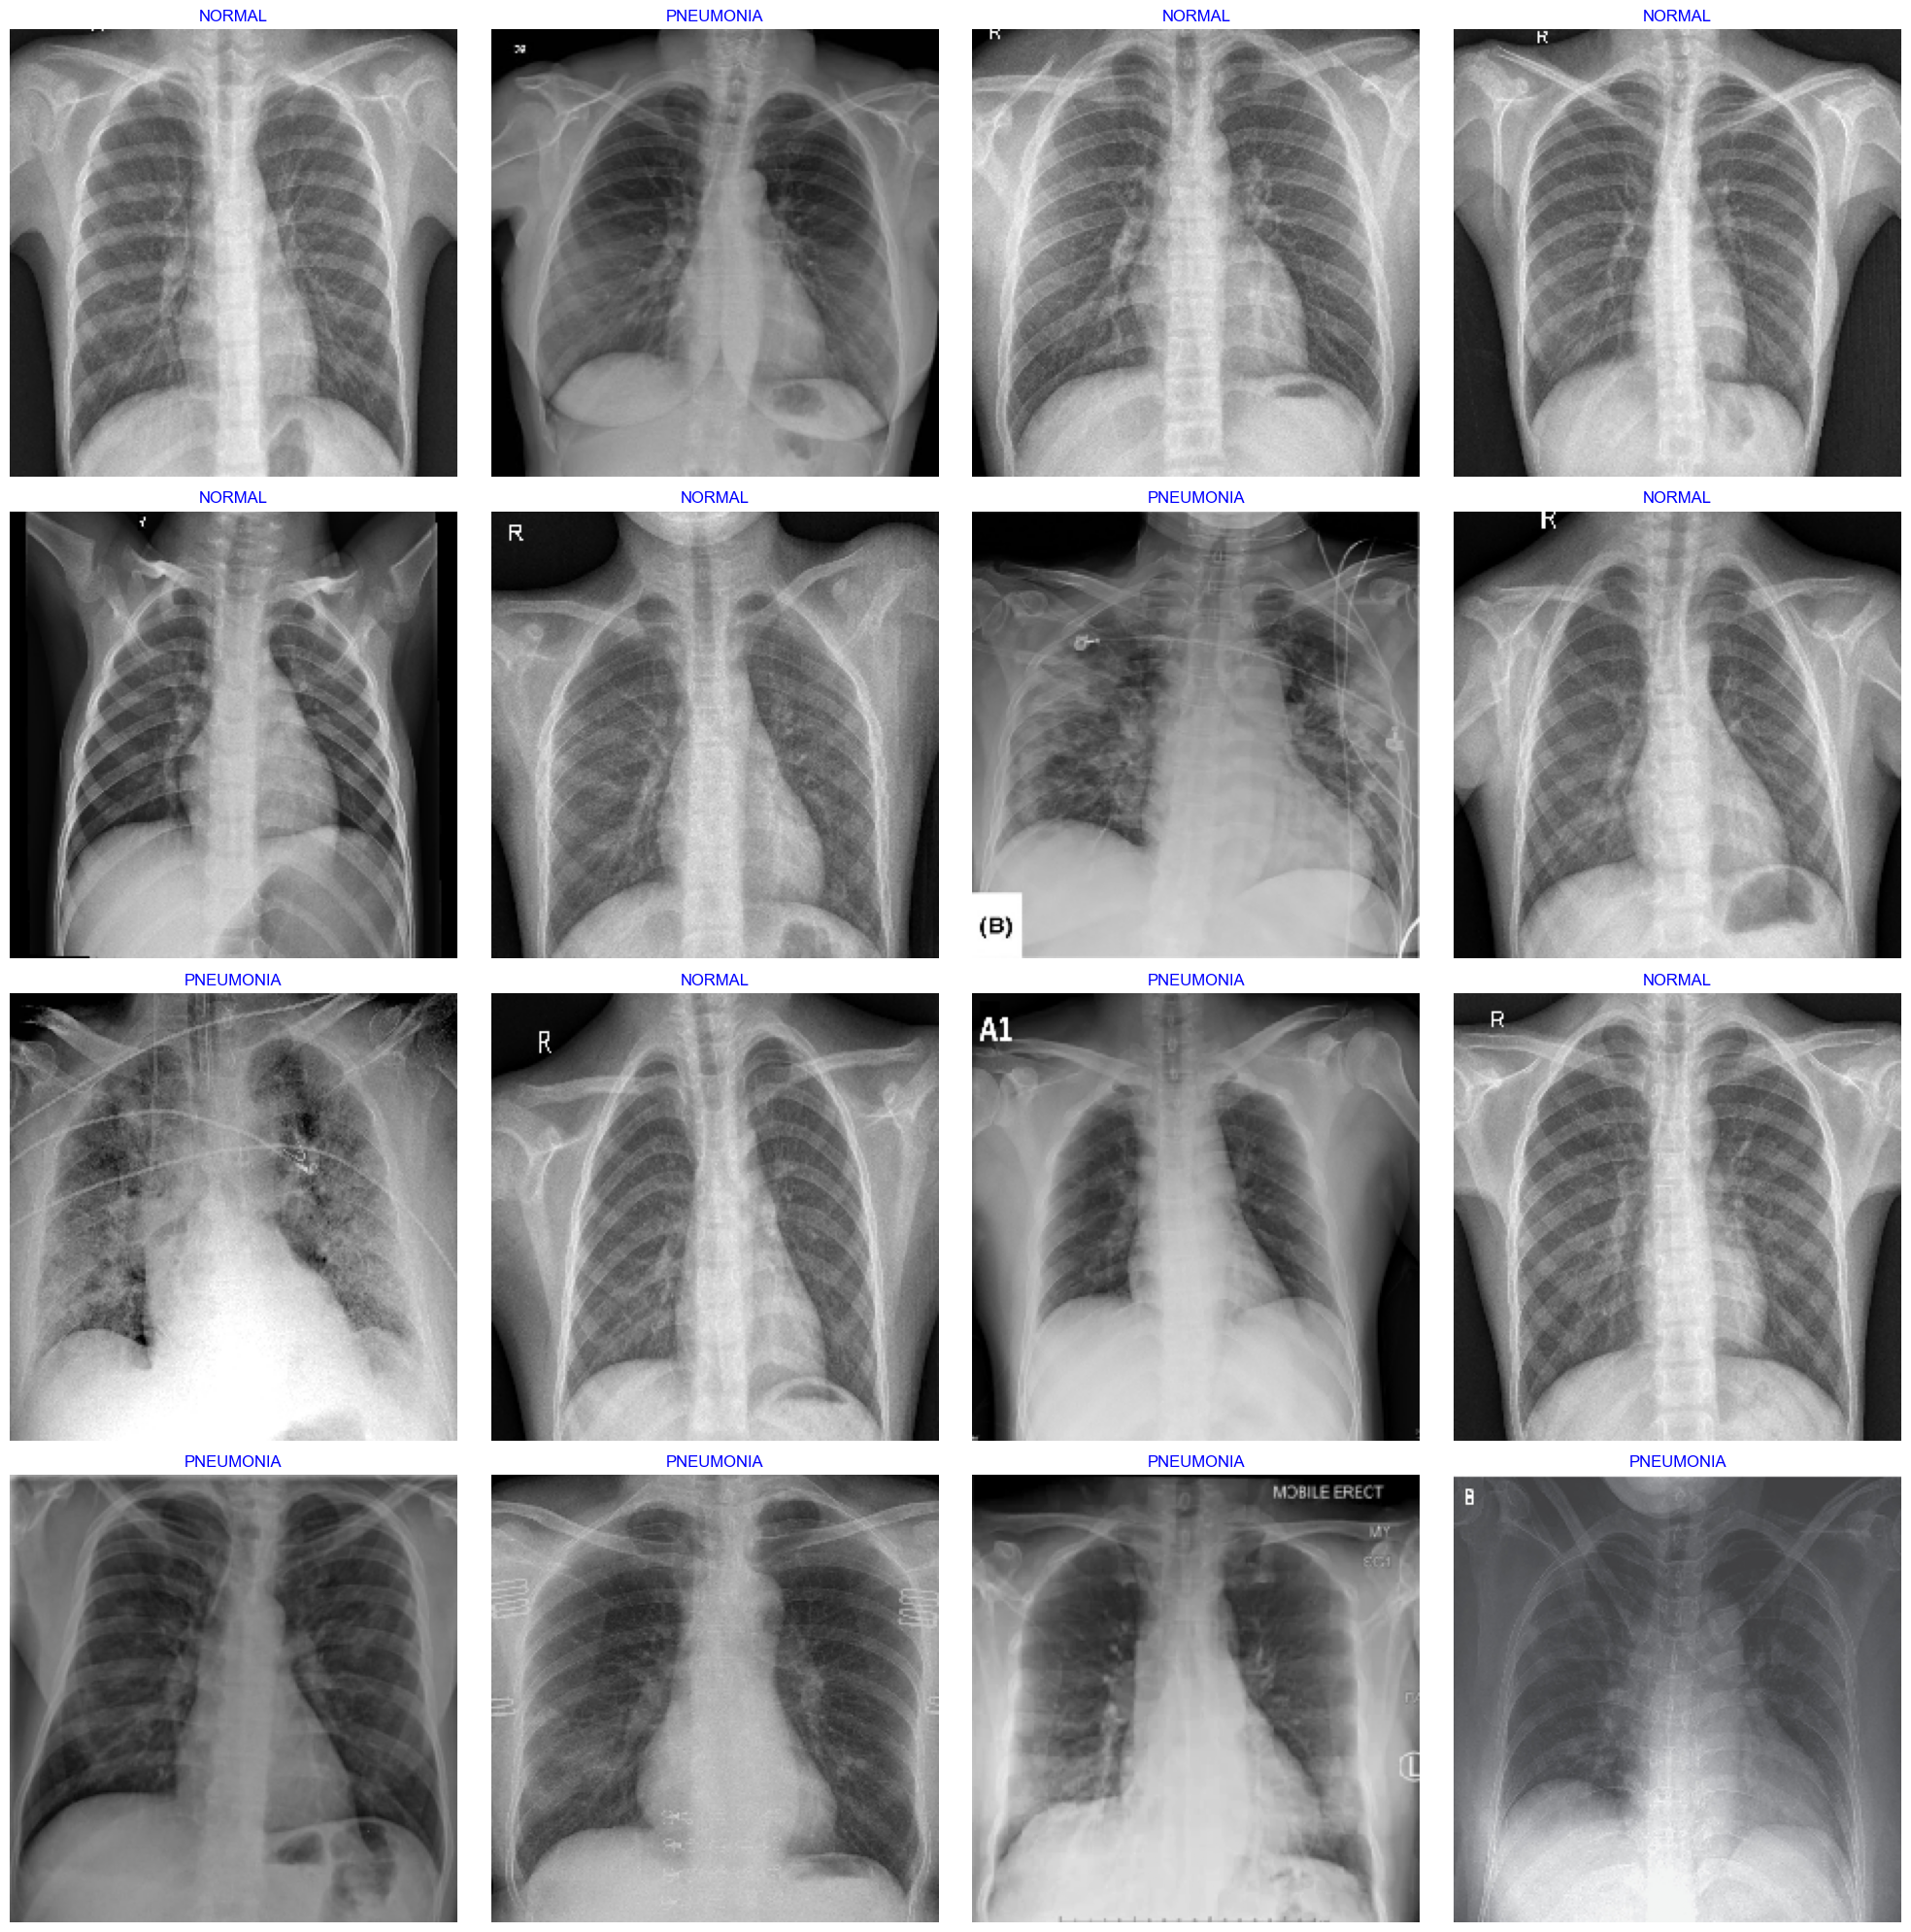

In [37]:
# Retrieve class indices dictionary from the training generator
g_dict = train_gen.class_indices      # Dictionary of {'class': index}
classes = list(g_dict.keys())         # List of class names as strings

# Load a single batch of images and labels from the training generator
images, labels = next(train_gen)      # Gets a batch of samples from the generator

# Create a figure for displaying the images
plt.figure(figsize=(20, 20))

# Loop to plot each image in the batch
for i in range(16):
    plt.subplot(4, 4, i + 1)              # Creates a 4x4 grid
    image = images[i] / 255               # Scales image data to 0-1 range
    plt.imshow(image)                     # Displays the image
    index = np.argmax(labels[i])          # Finds index of the maximum value in label vector
    class_name = classes[index]           # Retrieves the class name based on the index
    plt.title(class_name, color='blue', fontsize=12)  # Sets image title to class name
    plt.axis('off')                       # Removes axis for a cleaner look

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()          # Display the figure

## Initializing ResNet101 Base Model for Transfer Learning

In this section, we load a pre-trained ResNet101 model as the base for transfer learning. Using a pre-trained model leverages learned features from the ImageNet dataset, which can improve accuracy and reduce training time, especially when data is limited.

In [38]:
# Load the pre-trained ResNet101 model as the base
base_model = ResNet101(
    weights='imagenet',       # Loads weights pre-trained on the ImageNet dataset
    include_top=False,        # Excludes the top layers to allow for custom classification layers
    input_shape=(224, 224, 3), # Sets input shape to match the images in our dataset
    pooling='max'             # Applies max pooling to reduce dimensionality of feature maps
)

## Defining and Compiling the Deep Learning Model

In this section, we define the architecture of our deep learning model by adding custom layers on top of the pre-trained ResNet101 base model. The model is then compiled with an optimizer and loss function suitable for binary classification.

In [39]:
# Define the model architecture
model = Sequential([
  base_model,                         # Add the pre-trained ResNet101 base model
  Dense(256, activation='relu'),      # Dense layer with 256 units and ReLU activation
  Dense(128, activation='relu'),      # Dense layer with 128 units and ReLU activation
  Dropout(0.25),                      # Dropout layer with a rate of 25% to prevent overfitting
  Dense(64, activation='relu'),       # Dense layer with 64 units and ReLU activation
  Dense(2, activation='softmax')      # Final output layer with 2 units for binary classification (Softmax activation)
])

# Compile the model with Adamax optimizer and binary cross-entropy loss function
model.compile(optimizer=Adamax(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

## Early Stopping to Prevent Overfitting

In this section, we implement an EarlyStopping callback to monitor the validation loss during training. This helps prevent overfitting by stopping the training early if the model's performance on the validation set stops improving.

In [40]:
# Define EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor the validation loss during training
    patience=5,                # Stop training if no improvement in 'val_loss' after 5 epochs
    restore_best_weights=True  # Restore the best model weights when training stops
)

## Model Training with Early Stopping

In this section, we train the model using the training generator (train_gen) and validate it using the validation generator (valid_gen). The training process is monitored with the EarlyStopping callback to prevent overfitting.

In [41]:
# Train the model with EarlyStopping callback
history = model.fit(
    train_gen,                    # Training data generator
    epochs=10,                    # Train for 10 epochs
    validation_data=valid_gen,    # Validation data generator
    callbacks=[early_stopping]    # EarlyStopping callback to prevent overfitting
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7376 - loss: 1.8502 - val_accuracy: 0.4730 - val_loss: 17.6560
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9565 - loss: 0.1505 - val_accuracy: 0.4730 - val_loss: 56.3967
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9706 - loss: 0.1574 - val_accuracy: 0.4730 - val_loss: 39.9468
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9710 - loss: 0.1023 - val_accuracy: 0.4865 - val_loss: 18.7528
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9798 - loss: 0.0639 - val_accuracy: 0.5811 - val_loss: 12.5519
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9942 - loss: 0.0304 - val_accuracy: 0.7297 - val_loss: 7.1919
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9945 - loss: 0.0206 - val_accuracy: 0.8649 - val_loss: 1.4195
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9931 - loss: 0.0154 - val_accuracy: 0.8514 - val_

## Model Evaluation

In this section, we evaluate the performance of the trained model on the validation set (valid_gen). The evaluation results include both the loss and the accuracy of the model.

In [42]:
# Evaluate the model on the validation set
eval_results = model.evaluate(valid_gen)

# Print the evaluation results: Validation Loss and Validation Accuracy
print(f"Validation Loss: {eval_results[0]}, Validation Accuracy: {eval_results[1]}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.8551 - loss: 1.3066
Validation Loss: 1.4194767475128174, Validation Accuracy: 0.8648648858070374


## Visualizing Training and Validation Performance

In this section, we visualize the training and validation accuracy, as well as the loss, over the course of training. This helps to monitor the model's progress and determine if there is any overfitting or underfitting.

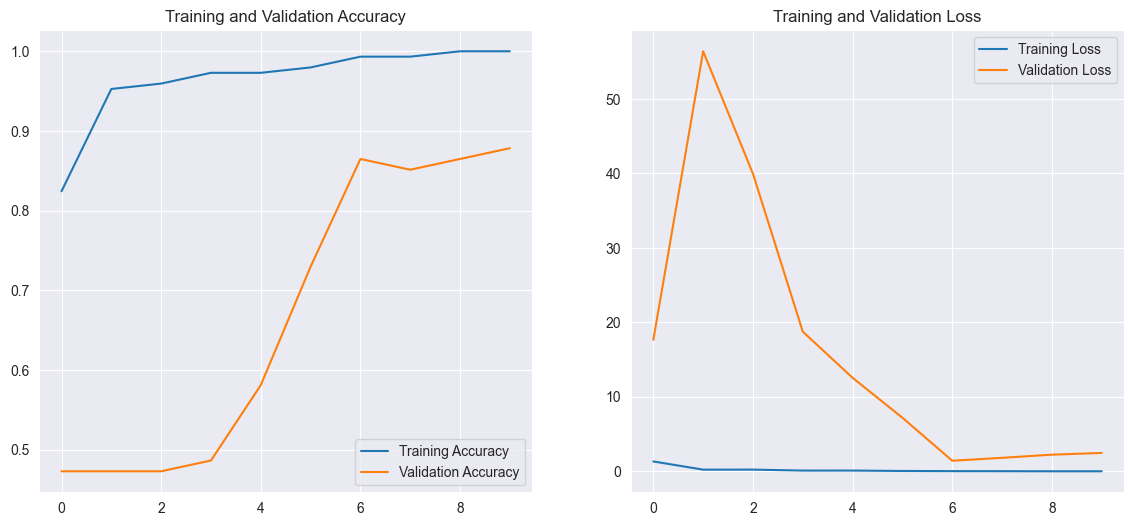

In [43]:
# Extract accuracy and loss history from the training process
acc = history.history['accuracy']         # Training accuracy
val_acc = history.history['val_accuracy'] # Validation accuracy
loss = history.history['loss']            # Training loss
val_loss = history.history['val_loss']    # Validation loss
epochs_range = range(len(acc))             # Epochs range for plotting

# Create a figure with two subplots: one for accuracy and one for loss
plt.figure(figsize=(14, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# Display the plots
plt.show()

## Visualizing Model Predictions

In this section, we visualize the model's predictions on a batch of validation images. We compare the predicted class with the true class labels to evaluate how well the model is performing.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


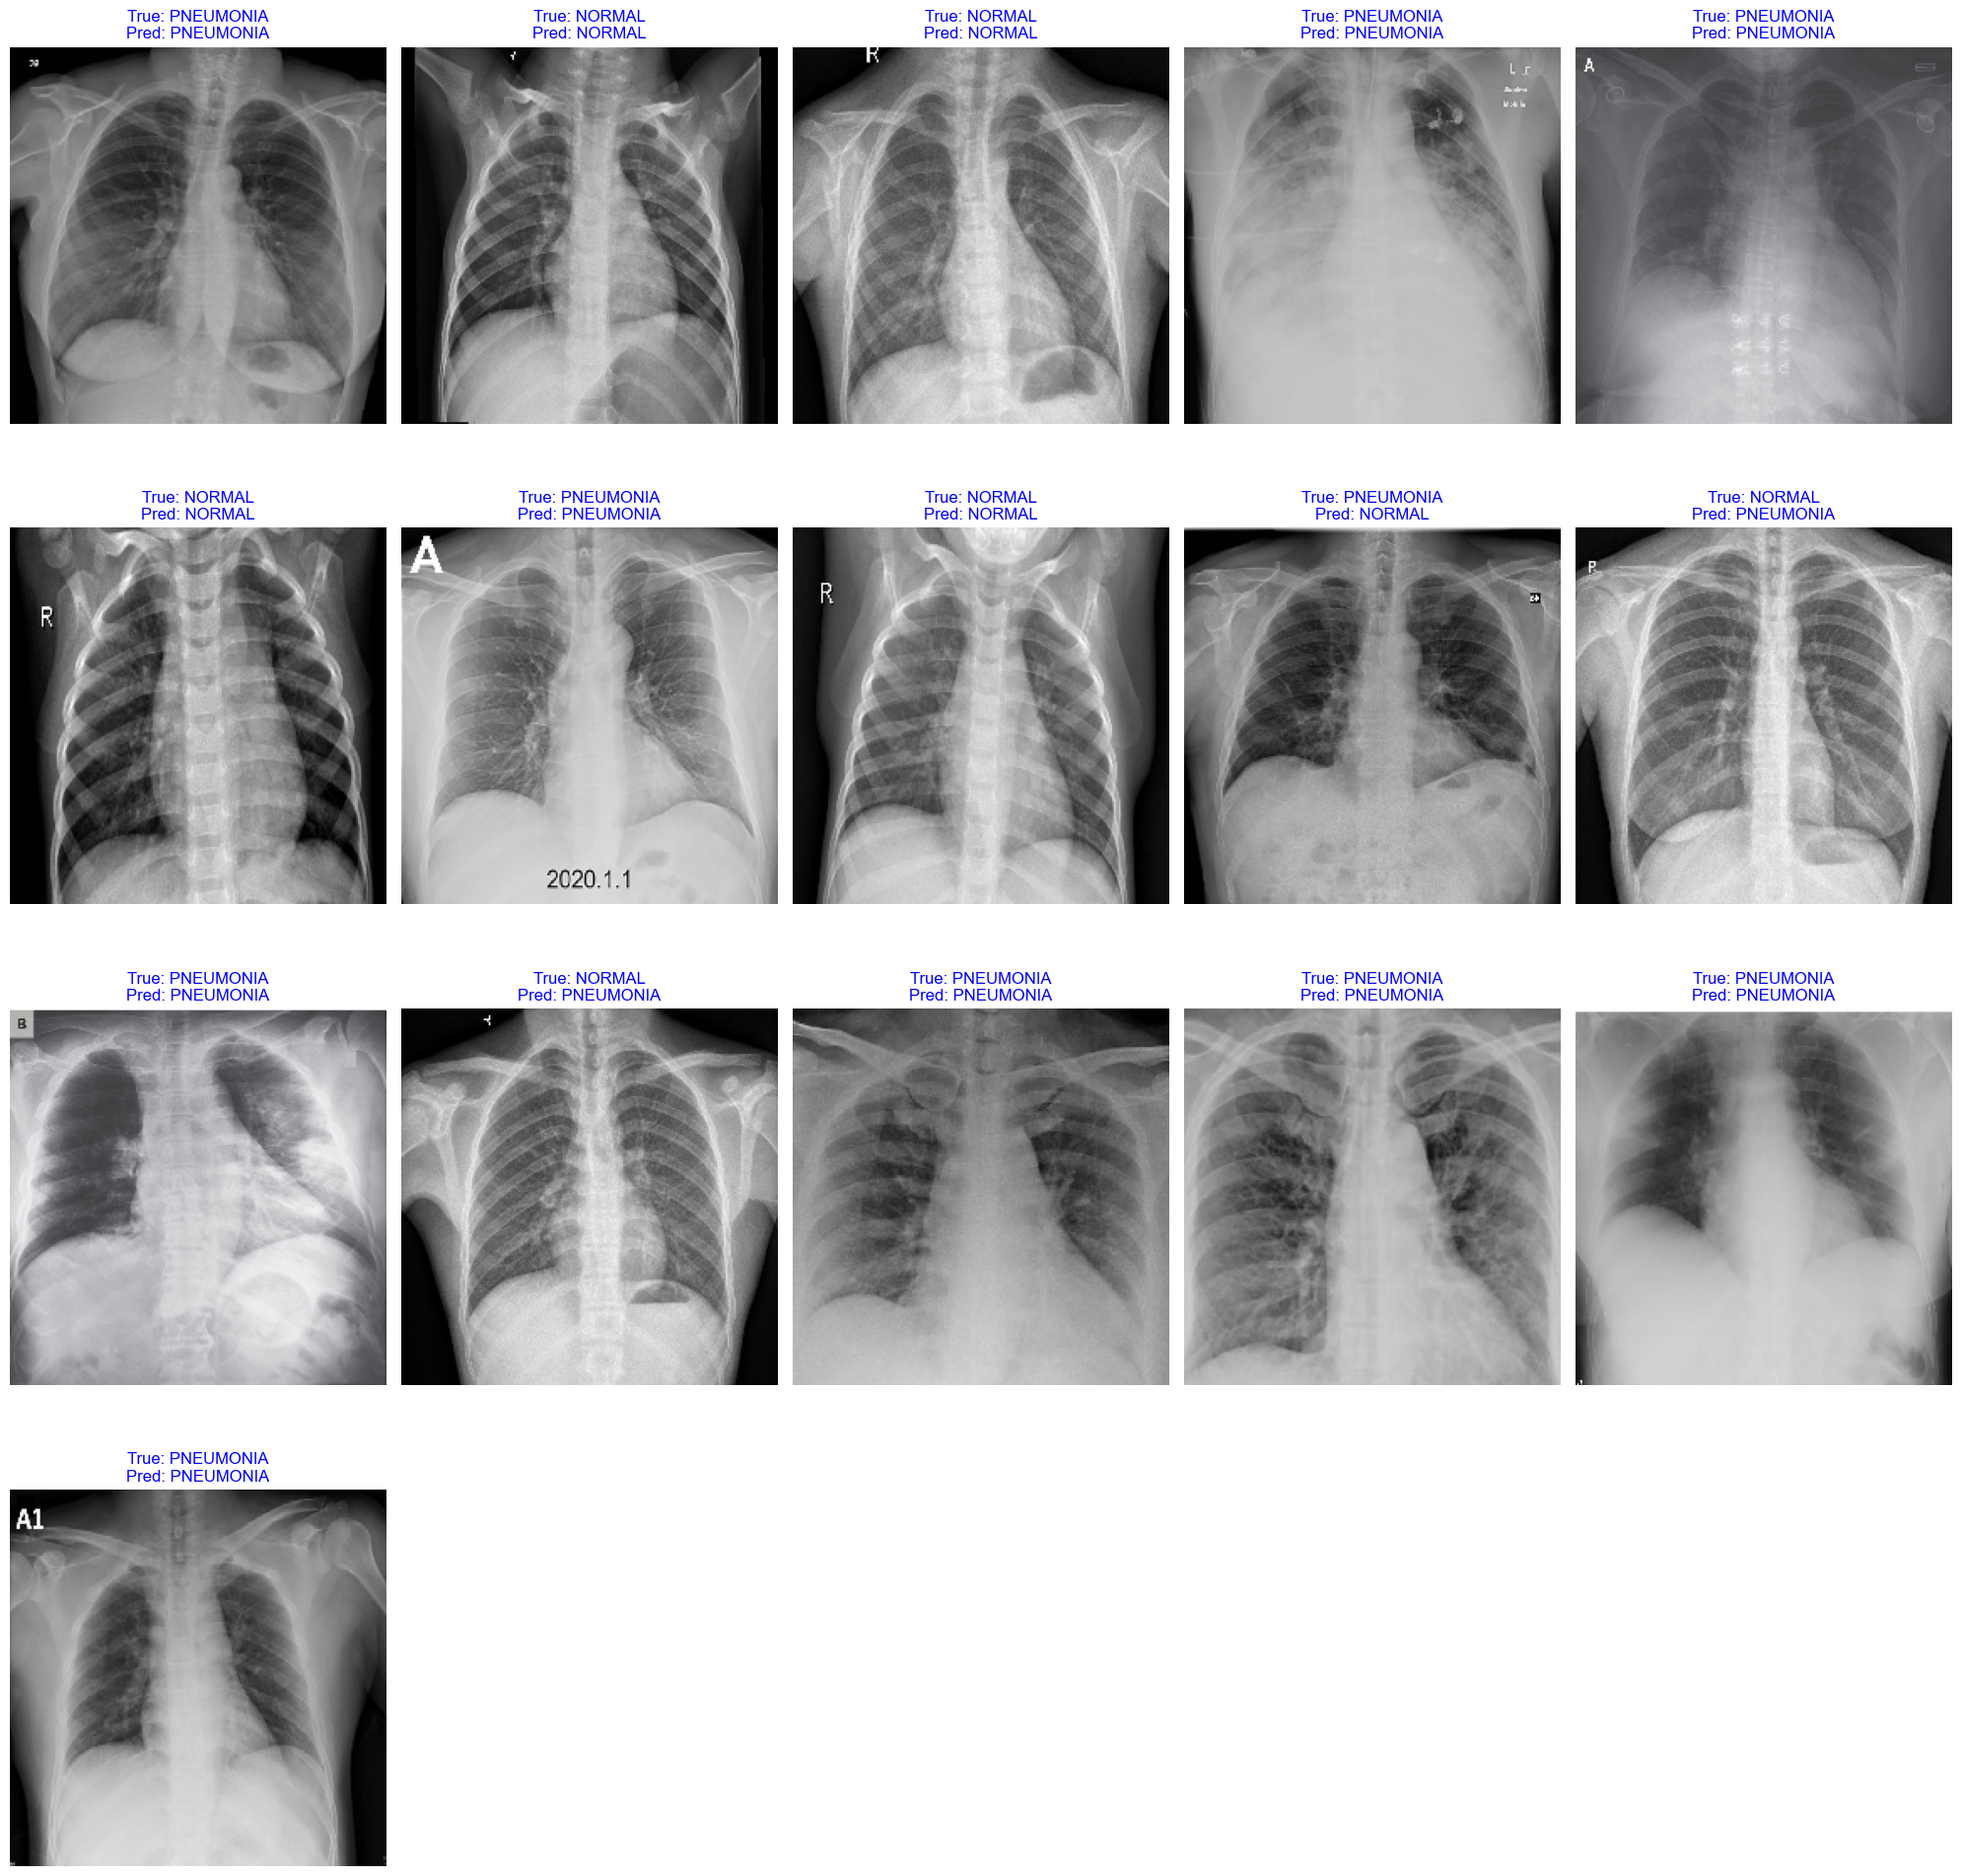

In [44]:
# Get a batch of images and true labels from the validation generator
images, true_labels = next(valid_gen)

# Perform predictions on the batch of images
predictions = model.predict(images)

# Get the predicted classes (using argmax to find the class with the highest probability)
predicted_classes = np.argmax(predictions, axis=1)

# Create a figure for displaying the images and predictions
plt.figure(figsize=(20, 20))

# Display 16 images with their true and predicted labels
for i in range(16):
    plt.subplot(4, 5, i + 1)  # Arrange the images in a grid (4 rows, 5 columns)
    image = images[i] / 255  # Normalize the image (if necessary)
    
    # Get the true class label from the true_labels
    true_class_index = np.argmax(true_labels[i])
    true_class = classes[true_class_index]
    
    # Get the predicted class label
    predicted_class = classes[predicted_classes[i]]
    
    # Display the image
    plt.imshow(image)
    
    # Title with the true and predicted class labels
    plt.title(f"True: {true_class}\nPred: {predicted_class}", color='blue', fontsize=12)
    plt.axis('off')  # Hide axis

# Ensure the layout is tight and display the plot
plt.tight_layout()
plt.show()